In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from scipy.stats import loguniform, randint

train_data = pd.read_csv('Train_data.csv')
test_data = pd.read_csv('Test_data.csv')

In [5]:
categorical_columns = ['protocol_type', 'service', 'flag']

train_features = train_data.drop('class', axis=1)
train_target = train_data['class']

train_features_encoded = pd.get_dummies(train_features, columns=categorical_columns)
test_features_encoded = pd.get_dummies(test_data, columns=categorical_columns)

train_features_aligned, test_features_aligned = train_features_encoded.align(
    test_features_encoded,
    join='left',
    axis=1,
    fill_value=0
)

label_encoder = LabelEncoder()
train_target_encoded = label_encoder.fit_transform(train_target)

x_train, x_val, y_train, y_val = train_test_split(
    train_features_aligned,
    train_target_encoded,
    test_size=0.2,
    random_state=42,
    stratify=train_target_encoded
)

In [6]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
test_features_scaled = scaler.transform(test_features_aligned)

mlp_classifier = MLPClassifier(activation='relu', solver='adam', random_state=42)

random_search_parameters = {
    'hidden_layer_sizes': [(16,), (32,), (48,), (64,), (80,), (96,), (112,), (128,)],
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'batch_size': [32, 64, 128, 256],
    'max_iter': randint(50, 300)
}

random_search = RandomizedSearchCV(
    estimator=mlp_classifier,
    param_distributions=random_search_parameters,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32, 64, ...], 'hidden_layer_sizes': [(16,), (32,), ...], 'learning_rate_init': <scipy.stats....0012C62BD1450>, 'max_iter': <scipy.stats....0012C62BD0E10>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Ran

In [ ]:
best_mlp = random_search.best_estimator_

print(random_search.best_params_)

val_predictions = best_mlp.predict(x_val_scaled)
print(classification_report(y_val, val_predictions, target_names=label_encoder.classes_))

test_predictions = best_mlp.predict(test_features_scaled)
test_predictions_labels = label_encoder.inverse_transform(test_predictions)

predictions_dataframe = pd.DataFrame({'prediction': test_predictions_labels})

{'batch_size': 128, 'hidden_layer_sizes': (96,), 'learning_rate_init': np.float64(0.0014899847475658245), 'max_iter': 99}
              precision    recall  f1-score   support

     anomaly       0.99      1.00      1.00      2349
      normal       1.00      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



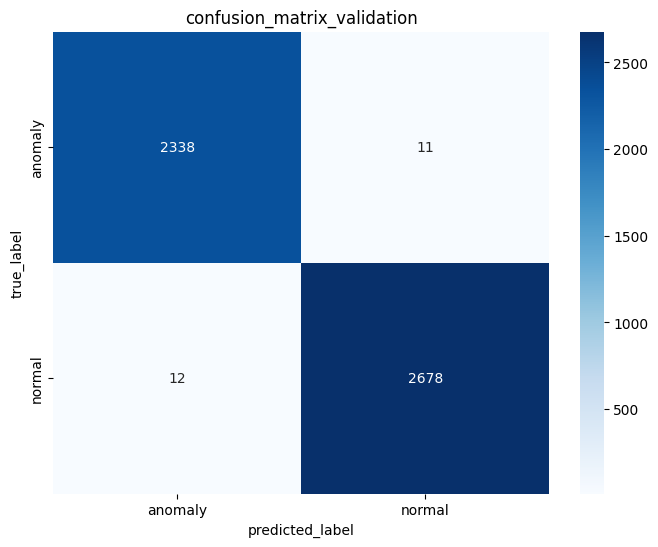

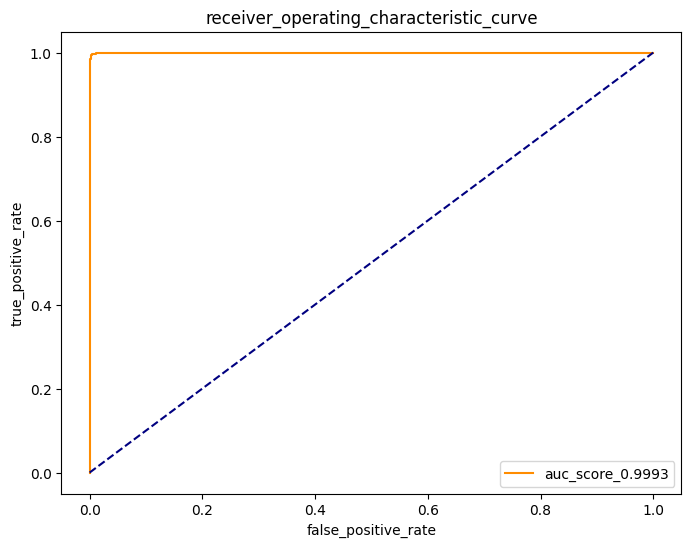

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

val_predictions_proba = best_mlp.predict_proba(x_val_scaled)[:, 1]

conf_matrix_val = confusion_matrix(y_val, val_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_val, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.xlabel('predicted_label')
plt.ylabel('true_label')
plt.title('confusion_matrix_validation')
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_val, val_predictions_proba)
roc_auc = auc(false_positive_rate, true_positive_rate)

plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, color='darkorange', label='auc_score_' + str(round(roc_auc, 4)))
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('false_positive_rate')
plt.ylabel('true_positive_rate')
plt.title('receiver_operating_characteristic_curve')
plt.legend(loc='lower right')
plt.show()